From the [Muon Tutorials for Single-cell RNA-seq and ATAC-seq integration](https://muon-tutorials.readthedocs.io/en/latest/single-cell-rna-atac/pbmc10k/1-Gene-Expression-Processing.html)

In [75]:
# Single-cell packages
import matplotlib.pyplot as plt
import muon as mu
import numpy as np

from pathlib import Path

# General helpful packages for data analysis and visualization
import pandas as pd
import scanpy as sc
import seaborn as sns
from muon import atac as ac  # the module containing function for scATAC data processing

# Setting figure parameters
sc.settings.verbosity = 0

DATA_DIR = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/raw/mESC_10x_data")
SAMPLE_NAME = "E7.5_rep1"

SAMPLE_DATA_DIR = DATA_DIR / SAMPLE_NAME
print(f"Loading data for sample {SAMPLE_NAME} from {DATA_DIR}...")
# print all files in the data directory
for file in SAMPLE_DATA_DIR.glob("*"):
    print(file)

Loading data for sample E7.5_rep1 from /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/raw/mESC_10x_data...
/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/raw/mESC_10x_data/E7.5_rep1/E7.5_rep1_fragments.sorted.tsv.gz
/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/raw/mESC_10x_data/E7.5_rep1/features.tsv.gz
/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/raw/mESC_10x_data/E7.5_rep1/E7.5_rep1_fragments.sorted.tsv.gz.tbi
/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/raw/mESC_10x_data/E7.5_rep1/fragments.tsv.gz
/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/raw/mESC_10x_data/E7.5_rep1/barcodes.tsv.gz
/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/raw/mESC_10x_data/E7.5_rep1/matrix.mtx.gz


In [76]:
mdata = mu.read_10x_mtx(SAMPLE_DATA_DIR)


/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [77]:
mdata.var_names_make_unique()
mdata

MuData object with n_obs × n_vars = 8936 × 232170
  var:	'gene_ids', 'feature_types'
  2 modalities
    rna:	8936 x 32285
      var:	'gene_ids', 'feature_types'
    atac:	8936 x 199885
      var:	'gene_ids', 'feature_types'

# RNA

In [78]:
rna = mdata.mod['rna']
rna

AnnData object with n_obs × n_vars = 8936 × 32285
    var: 'gene_ids', 'feature_types'

## Preprocessing

### QC

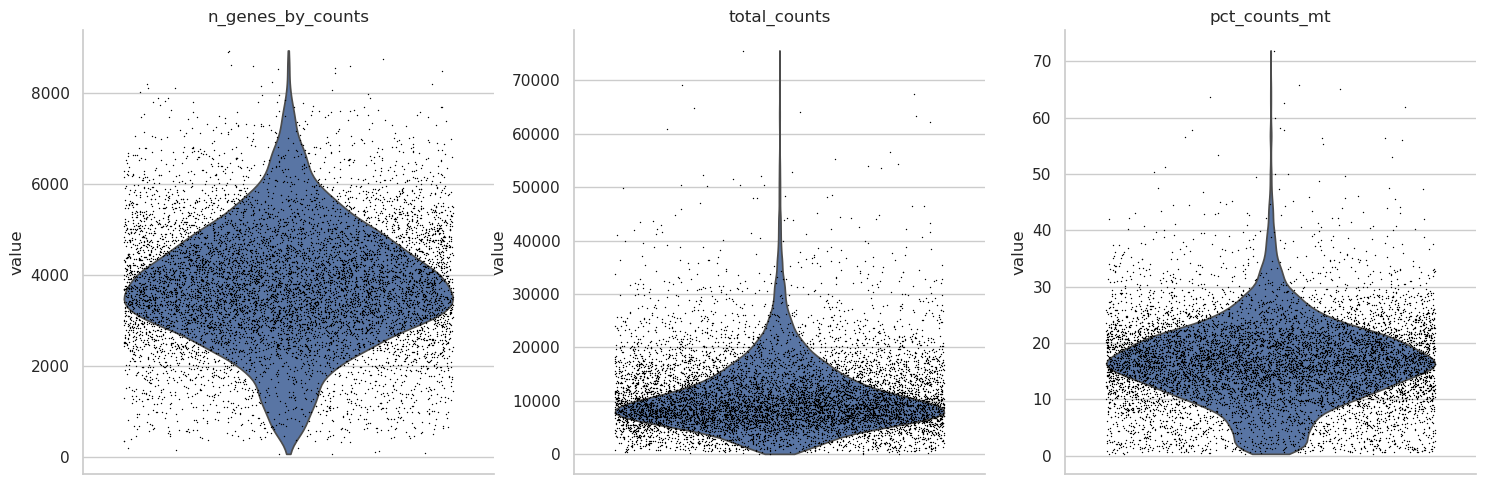

In [79]:
rna.var['mt'] = rna.var_names.str.startswith('mt-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(rna, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

sc.pl.violin(rna, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True)

Filter genes and cells based on the thresholds above

In [80]:
MIN_CELLS_PER_GENE = 3

MIN_GENES_PER_CELL = 200
MAX_GENES_PER_CELL = 5000

MAX_TOTAL_COUNTS = 15000
MAX_PCT_COUNTS_MT = 20

mu.pp.filter_var(rna, 'n_cells_by_counts', lambda x: x >= MIN_CELLS_PER_GENE)
mu.pp.filter_obs(rna, 'n_genes_by_counts', lambda x: (x >= MIN_GENES_PER_CELL) & (x <= MAX_GENES_PER_CELL))
mu.pp.filter_obs(rna, 'total_counts', lambda x: x <= MAX_TOTAL_COUNTS)
mu.pp.filter_obs(rna, 'pct_counts_mt', lambda x: x <= MAX_PCT_COUNTS_MT)

Check to see how the data looks after filtering.

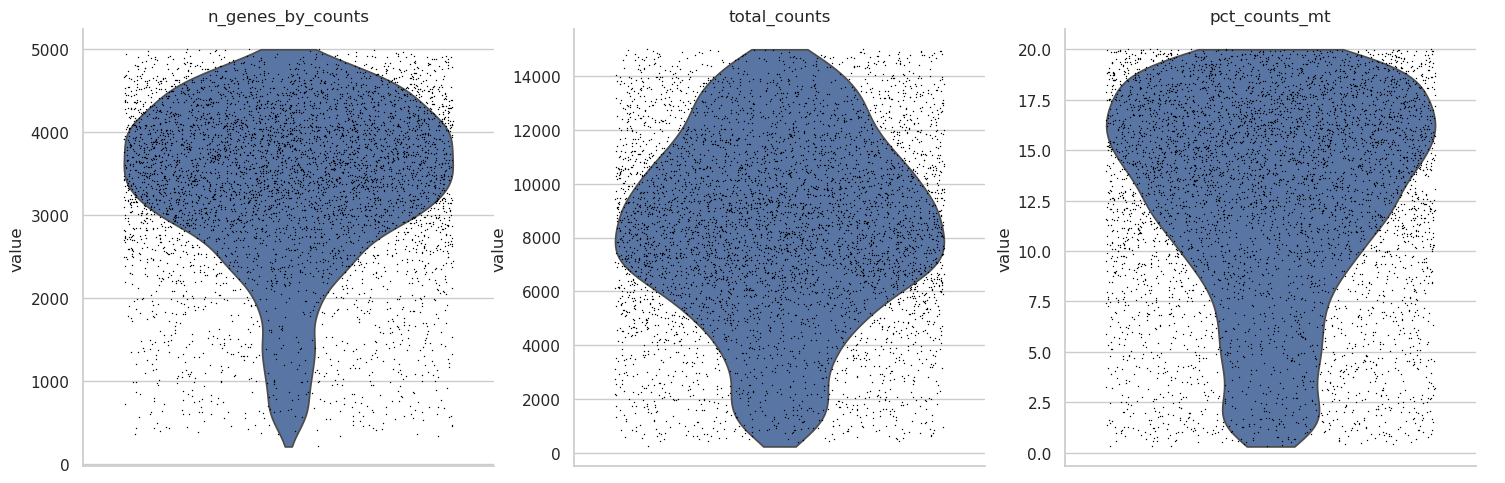

In [81]:
sc.pl.violin(rna, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True)

### Normalization

In [82]:
sc.pp.normalize_total(rna, target_sum=1e4)
sc.pp.log1p(rna)

### Feature Selection

We will label highly variable genes that we'll use for downstream analysis.

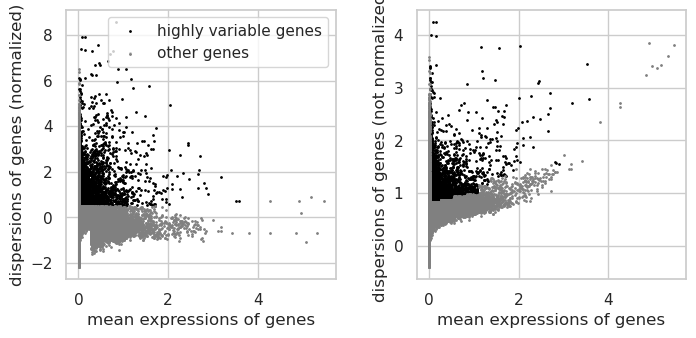

In [83]:
MIN_RNA_DISP = 0.5
sc.pp.highly_variable_genes(rna, min_mean=0.02, max_mean=4, min_disp=MIN_RNA_DISP)
sc.pl.highly_variable_genes(rna)

In [84]:
np.sum(rna.var.highly_variable)

np.int64(3310)

### Scaling

We'll save log-normalized counts in a `.raw` slot:

In [85]:
rna.raw = rna

... and scale the log-normalized counts to zero mean and unit variance

In [86]:
sc.pp.scale(rna, max_value=10)

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


## Analysis

### PCA and Neighborhood Graph

We will visualize some genes that we expect to see in the mESC cells.

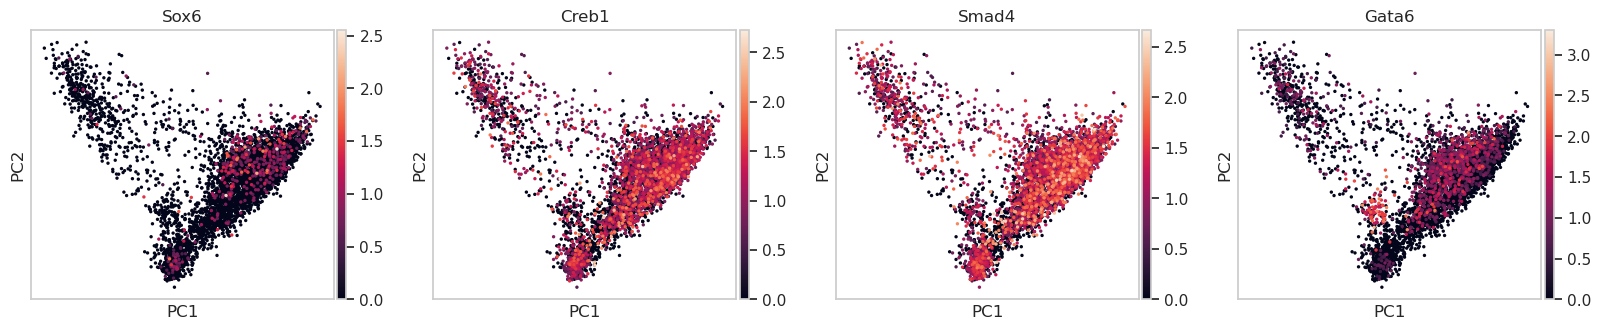

In [87]:
sc.tl.pca(rna, svd_solver='arpack')
sc.pl.pca(rna, color=['Sox6', 'Creb1', 'Smad4', 'Gata6'])

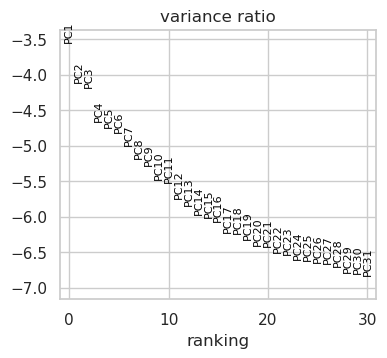

In [88]:
sc.pl.pca_variance_ratio(rna, log=True)

### Neighbors

In [89]:
sc.pp.neighbors(rna, n_neighbors=10, n_pcs=20)

### Non-linear dimensionality reduction and clustering

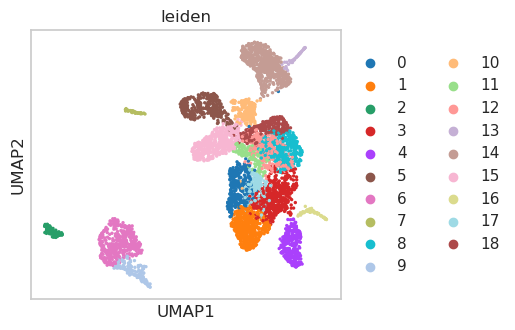

In [90]:
sc.tl.umap(rna, spread=1., min_dist=.5, random_state=11)
sc.tl.leiden(rna, flavor="igraph", n_iterations=2)
sc.pl.umap(rna, color=["leiden"])

# ATAC

In [91]:
atac = mdata.mod['atac']
atac  # an AnnData object

AnnData object with n_obs × n_vars = 8936 × 199885
    var: 'gene_ids', 'feature_types'

## Preprocessing

### QC

Filter out cells with too few peaks and peaks detected in too few cells.

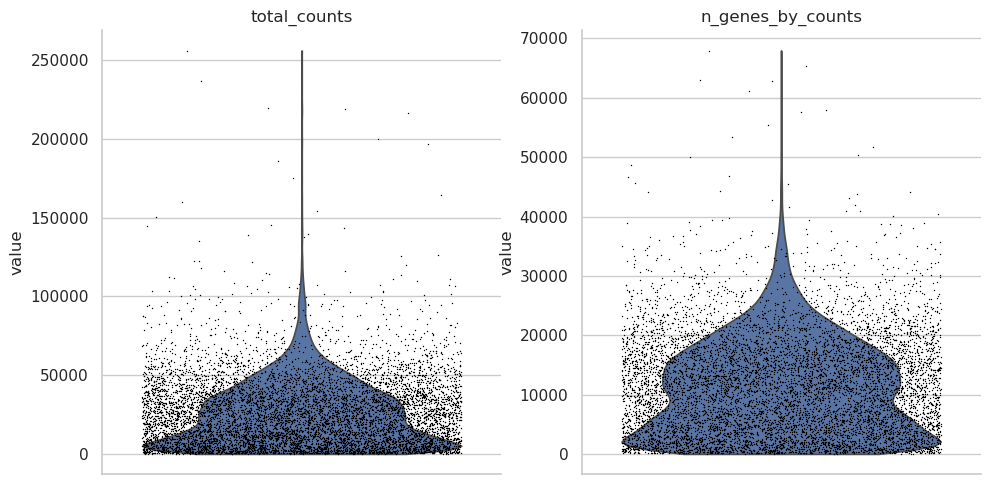

In [92]:
sc.pp.calculate_qc_metrics(atac, percent_top=None, log1p=False, inplace=True)
sc.pl.violin(atac, ['total_counts', 'n_genes_by_counts'], jitter=0.4, multi_panel=True)

In [93]:
mu.pp.filter_var(atac, 'n_cells_by_counts', lambda x: x >= 10)
# This is analogous to
#   sc.pp.filter_genes(rna, min_cells=10)
# but does in-place filtering and avoids copying the object

mu.pp.filter_obs(atac, 'n_genes_by_counts', lambda x: (x >= 2000) & (x <= 15000))
# This is analogous to
#   sc.pp.filter_cells(atac, max_genes=15000)
#   sc.pp.filter_cells(atac, min_genes=2000)
# but does in-place filtering avoiding copying the object

mu.pp.filter_obs(atac, 'total_counts', lambda x: (x >= 4000) & (x <= 40000))

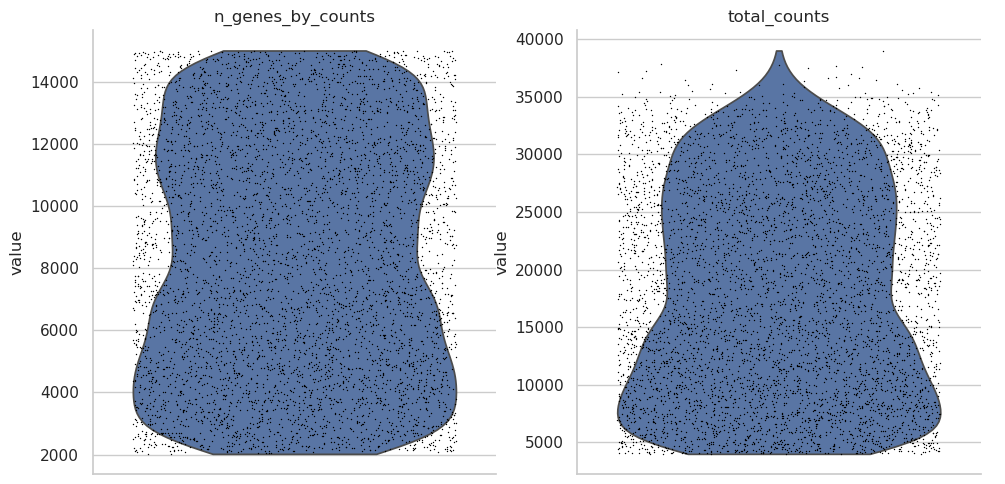

In [94]:
sc.pl.violin(atac, ['n_genes_by_counts', 'total_counts'], jitter=0.4, multi_panel=True)


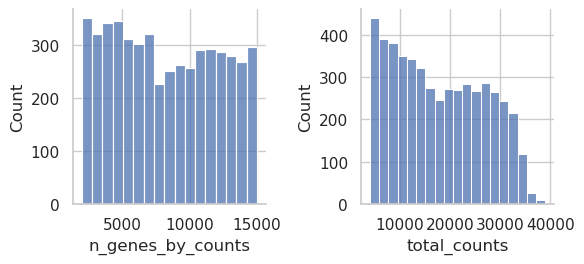

In [95]:
mu.pl.histogram(atac, ['n_genes_by_counts', 'total_counts'])

### ATAC-specific QC
There are a few expectations about how ATAC-seq data looks like as noted in the [hitchhiker’s guide to ATAC-seq data analysis](https://genomebiology.biomedcentral.com/articles/10.1186/s13059-020-1929-3#citeas) for instance


#### Nucleosome Signal

Fragment size distribution typically reflects nucleosome binding pattern showing enrichment around values corresponding to fragments bound to a single nucleosome (between 147 bp and 294 bp) as well as nucleosome-free fragments (shorter than 147 bp).

['GL456210.1', 'GL456211.1', 'GL456212.1', 'GL456216.1', 'GL456219.1', 'GL456221.1', 'GL456233.1', 'GL456350.1', 'GL456354.1', 'JH584292.1', 'JH584295.1', 'JH584296.1', 'JH584297.1', 'JH584299.1', 'JH584304.1', 'chr1', 'chr10', 'chr11', 'chr12', 'chr13']
{'fragments': '/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/raw/mESC_10x_data/E7.5_rep1/E7.5_rep1_fragments.sorted.tsv.gz'}
/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/raw/mESC_10x_data/E7.5_rep1/E7.5_rep1_fragments.sorted.tsv.gz
chr1:3000000-4000000 chr1	3000081	3000621	AATCCCTGTGTTGCTT-1	1


Fetching Regions...: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  4.76it/s]


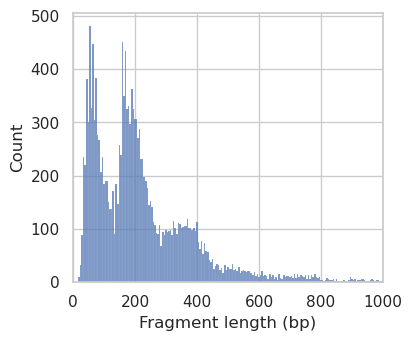

In [96]:
import pysam

frag_path = str(SAMPLE_DATA_DIR / "E7.5_rep1_fragments.sorted.tsv.gz")

tbx = pysam.TabixFile(frag_path)
print(tbx.contigs[:20])

# register the fragment file with the ATAC AnnData
ac.tl.locate_fragments(atac, fragments=frag_path)

print(atac.uns["files"])
print(atac.uns["files"]["fragments"])
# optional grouping column if you want one
atac.obs["NS"] = 1

def find_nonempty_region(tbx, chrom="chr1", window=1_000_000, max_end=200_000_000):
    for start in range(0, max_end, window):
        rows = list(tbx.fetch(chrom, start, start + window))
        if rows:
            return f"{chrom}:{start}-{start+window}", rows[0]
    return None, None

region, example = find_nonempty_region(tbx, chrom="chr1")
print(region, example)

ac.pl.fragment_histogram(atac, region=region)

The ratio of mono-nucleosome cut fragments to nucleosome-free fragments can be called nucleosome signal, and it can be estimated using a subset of fragments.

In [97]:
ac.tl.nucleosome_signal(atac, n=1e6)

Reading Fragments: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000000/1000000 [00:03<00:00, 323195.29it/s]


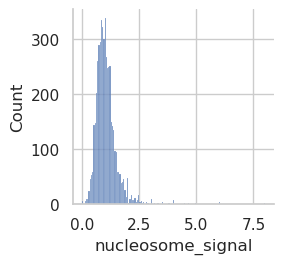

In [98]:
mu.pl.histogram(atac, "nucleosome_signal", kde=False)

#### TSS Enrichment

We can expect chromatin accessibility enriched around transcription start sites (TSS) compared to accessibility of flanking regions. Thus this measure averaged across multiple genes can serve as one more quality control metric.

The positions of transcription start sites can be obtained from the interval field of the gene annotation in the rna modality:

In [99]:
import pandas as pd

tss_path = "/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/genome_data/genome_annotation/mm10/gene_tss.bed"

# Load BED and rename columns to avoid collisions
tss_df = pd.read_csv(
    tss_path,
    sep="\t",
    header=None,
    names=["tss_chrom", "tss_start", "tss_end", "tss_gene"]
)

var = rna.var.copy()
var["original_var_name"] = var.index

# Match RNA var_names (usually gene symbols) to BED gene column
var = var.merge(
    tss_df,
    left_index=True,
    right_on="tss_gene",
    how="left"
).set_index("original_var_name")

# Build interval only for matched genes
var["interval"] = pd.NA
mask = var["tss_chrom"].notna() & var["tss_start"].notna() & var["tss_end"].notna()

var.loc[mask, "interval"] = (
    var.loc[mask, "tss_chrom"].astype(str) + ":" +
    var.loc[mask, "tss_start"].astype(int).astype(str) + "-" +
    var.loc[mask, "tss_end"].astype(int).astype(str)
)

# Optional: add the exact column names Muon may expect later
var["Chromosome"] = var["tss_chrom"]
var["Start"] = var["tss_start"]
var["End"] = var["tss_end"]

rna.var = var

# keep only genes with TSS annotation
rna_tss = rna[:, rna.var["interval"].notna()].copy()

In [100]:
genes = ac.tl.get_gene_annotation_from_rna(rna_tss)
genes.head(3)

,Chromosome,Start,End,gene_id,gene_name
original_var_name,,,,,
AI597479,chr1,43098709,43098709,ENSMUSG00000010290,AI597479
BC055402,chr1,57214996,57214996,ENSMUSG00000101429,BC055402
AA986860,chr1,130731975,130731975,ENSMUSG00000042510,AA986860


TSS enrichment function will return an AnnData object with cells x bases dimensions where bases correspond to positions around TSS and are defined by extend_upstream and extend_downstream parameters, each of them being 1000 bp by default. It will also record tss_score in the original object.

Fetching Regions...:   0%|                                                                                                                                                                           | 0/141 [00:00<?, ?it/s]

Fetching Regions...: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 141/141 [00:03<00:00, 44.10it/s]
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


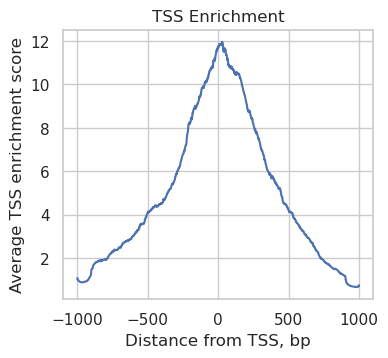

In [103]:
# rna_tss should contain only genes with non-missing interval strings
genes = ac.tl.get_gene_annotation_from_rna(rna_tss)

# now use those features explicitly
tss = ac.tl.tss_enrichment(mdata, features=genes, n_tss=1000)

# plot
ac.pl.tss_enrichment(tss)

### Normalization

In [ ]:
# Save original counts
atac.layers["counts"] = atac.X

There can be multiple options for ATAC-seq data normalisation.

One is latent semantic indexing that is frequently used for processing ATAC-seq datasets. First, it constructs term-document matrix from the original count matrix. Then the singular value decomposition (SVD) — the same technique that convential principal component analysis uses — is used to generate LSI components. Note that there are different flavours of computing TF-IDF, e.g. see this blog post about that.

TF-IDF normalisation is implemented in the muon’s ATAC module:

In [104]:
ac.pp.tfidf(atac, scale_factor=1e4)

Here we will use the same log-normalisation and PCA that we are used to from scRNA-seq analysis. We notice on this data it yields PC & UMAP spaces similar to the one generated on scRNA-seq counts.

In [105]:
sc.pp.normalize_per_cell(atac, counts_per_cell_after=1e4)
sc.pp.log1p(atac)

/tmp/ipykernel_2667429/27188036.py:1: FutureWarning: Use sc.pp.normalize_total instead
  sc.pp.normalize_per_cell(atac, counts_per_cell_after=1e4)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:590: FutureWarning: Use sc.pp.normalize_total instead
  normalize_per_cell(


### Feature Selection

We will label highly variable peaks that we’ll use for downstream analysis.

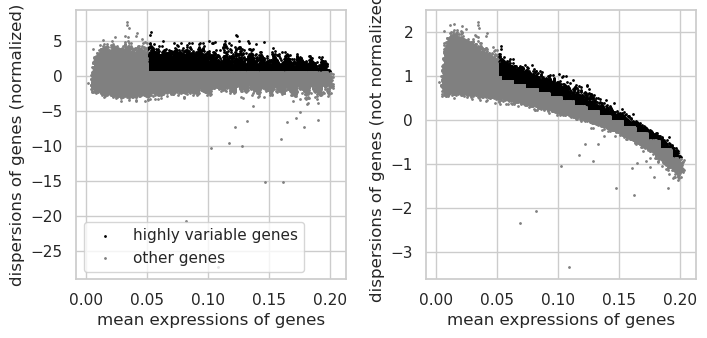

In [106]:
sc.pp.highly_variable_genes(atac, min_mean=0.05, max_mean=1.5, min_disp=.5)
sc.pl.highly_variable_genes(atac)

In [107]:
np.sum(atac.var.highly_variable)

np.int64(16956)

### Scaling

For uniformity, and for consequent visualisation, we’ll save log-transformed counts in a .raw slot:

In [ ]:
atac.raw = atac

## Analysis

After filtering out low-quality cells, normalising the counts matrix, and selecting highly variable peaks, we can already use this data for multimodal integration.

However, as in the case of gene expression, we will study this data individually first and will run PCA on the scaled matrix, compute cell neighbourhood graph, and perform clustering to define cell types. This might be useful later to compare cell type definition between modalities.